In [1]:
# the code was produced by Claude 

In [2]:
print('''

Delaney / ESOL solubility GCN — molecule and atom embeddings
============================================================
 
What this script does, end to end
---------------------------------
1. Loads the Delaney/ESOL dataset via PyTorch Geometric.
2. Defines a 3-layer GCN regressor (`GCNRegressor`) that predicts logS from
   molecular graphs.
3. Trains it for a configurable number of epochs.
4. Extracts MOLECULE-LEVEL embeddings (one 64-dim vector per molecule) and
   saves them next to the SMILES + logS in `delaney_gnn_embeddings.csv`.
5. Extracts ATOM-LEVEL embeddings (one 64-dim vector per atom) and saves them
   in long format (one row per atom) in `delaney_gnn_atom_embeddings.csv`.
6. Visualizes both:
     - PCA of molecule embeddings, colored by logS
     - PCA of atom embeddings, colored by element
     - One molecule with atoms colored by their predicted "logS contribution"
7. Trains a Random Forest on the GCN molecule embeddings as a sanity check
   that the embeddings carry the solubility signal.
 
Why the embeddings exist where they do
--------------------------------------
In a GCN, the natural "molecule embedding" is the output of `global_mean_pool`
— that's the graph-level vector the model builds before its final MLP head.
In this `GCNRegressor` that vector is 64-dimensional (HIDDEN_DIM), analogous
to the 384-dim CLS-token embedding produced by ChemBERTa.
 
The cleanest way to expose it is to add an `embed()` method that runs the
convs + pool and stops there. No retraining required — the same weights are
reused, you just expose an extra entry point. The full `forward()` keeps
working exactly as before.
 
For ATOM embeddings, you stop one step earlier — before pooling. After three
GCN layers each atom has aggregated information from its neighborhood up to
3 bonds away (the receptive field of a 3-layer GCN). That gives one vector
per atom; pooling is what collapses them into one vector per molecule.
 
A note on the choice of layer
-----------------------------
`embed()` returns the embedding RIGHT AFTER `global_mean_pool` — before any
dropout or MLP head — because that's the most "pure" molecule representation.
If you instead want what the regression head sees just before the final
`lin2`, you can take `F.relu(self.lin1(...))` and you'll get a 64-dim vector
that's been task-adapted. The pre-MLP one is generally the better choice for
transfer learning; the post-MLP one is better when you specifically care
about solubility-relevant axes.
 
Requirements:
    pip install torch torch_geometric rdkit
    pip install scikit-learn pandas matplotlib scipy

''')



Delaney / ESOL solubility GCN — molecule and atom embeddings
 
What this script does, end to end
---------------------------------
1. Loads the Delaney/ESOL dataset via PyTorch Geometric.
2. Defines a 3-layer GCN regressor (`GCNRegressor`) that predicts logS from
   molecular graphs.
3. Trains it for a configurable number of epochs.
4. Extracts MOLECULE-LEVEL embeddings (one 64-dim vector per molecule) and
   saves them next to the SMILES + logS in `delaney_gnn_embeddings.csv`.
5. Extracts ATOM-LEVEL embeddings (one 64-dim vector per atom) and saves them
   in long format (one row per atom) in `delaney_gnn_atom_embeddings.csv`.
6. Visualizes both:
     - PCA of molecule embeddings, colored by logS
     - PCA of atom embeddings, colored by element
     - One molecule with atoms colored by their predicted "logS contribution"
7. Trains a Random Forest on the GCN molecule embeddings as a sanity check
   that the embeddings carry the solubility signal.
 
Why the embeddings exist where the

In [3]:
# ---------------------------------------------------------------------------
# 0. Configuration
# ---------------------------------------------------------------------------
import os
 
N_EPOCHS      = 100
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
HIDDEN_DIM    = 64
DROPOUT       = 0.2
SEED          = 42
 
OUTPUT_DIR    = "./delaney_gnn_embeddings_run"
DATA_DIR      = "./data/MoleculeNet"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [4]:
# ---------------------------------------------------------------------------
# 1. Imports
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
 
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
 
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
 
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
 
torch.manual_seed(SEED)
np.random.seed(SEED)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
 

PyTorch  : 2.5.1+cu121
Device   : cuda


In [5]:

# ---------------------------------------------------------------------------
# 2. Data — load ESOL/Delaney
# ---------------------------------------------------------------------------
dataset = MoleculeNet(root=DATA_DIR, name="ESOL")
print(f"\nDataset      : {dataset}")
print(f"Num molecules: {len(dataset)}")
print(f"Atom feat dim: {dataset.num_node_features}")
 
# Target normalization (z-score)
y_all_raw = torch.cat([d.y for d in dataset]).view(-1).float()
y_mean    = y_all_raw.mean().item()
y_std     = y_all_raw.std().item()
print(f"y mean / std : {y_mean:.4f} / {y_std:.4f}")
 
# 80 / 10 / 10 random split, reproducible
n         = len(dataset)
n_train   = int(0.8 * n)
n_valid   = int(0.1 * n)
n_test    = n - n_train - n_valid
generator = torch.Generator().manual_seed(SEED)
train_ds, valid_ds, test_ds = random_split(
    dataset, [n_train, n_valid, n_test], generator=generator
)
print(f"Splits       : train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")



Dataset      : ESOL(1128)
Num molecules: 1128
Atom feat dim: 9
y mean / std : -3.0501 / 2.0964
Splits       : train=902  valid=112  test=114


In [6]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False) 

In [7]:
train_loader

In [8]:
valid_loader

In [9]:
test_loader 

In [10]:
# ---------------------------------------------------------------------------
# 3. Model — 3-layer GCN, with embed() and embed_atoms() entry points
# ---------------------------------------------------------------------------
class GCNRegressor(nn.Module):
    """
    Three GCN layers + mean-pool + 2-layer MLP head.
 
    Adding embed() and embed_atoms() does NOT change training — they just
    expose intermediate vectors. forward() routes through them so there's
    only one definition of the conv stack.
    """
    def __init__(self, in_dim, hidden_dim=64, out_dim=1, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.bn3   = nn.BatchNorm1d(hidden_dim)
        self.lin1  = nn.Linear(hidden_dim, hidden_dim)
        self.lin2  = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout
 
    def embed_atoms(self, x, edge_index):
        """Per-atom (per-node) embeddings — shape (n_atoms_in_batch, hidden_dim)."""
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return x
 
    def embed(self, x, edge_index, batch):
        """Molecule-level embedding — shape (n_molecules_in_batch, hidden_dim)."""
        h = self.embed_atoms(x, edge_index)
        return global_mean_pool(h, batch)
 
    def forward(self, x, edge_index, batch):
        z = self.embed(x, edge_index, batch)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = F.relu(self.lin1(z))
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = self.lin2(z)
        return z.squeeze(-1)
 
 


In [11]:
model     = GCNRegressor(in_dim=dataset.num_node_features,
                         hidden_dim=HIDDEN_DIM, 
                         dropout=DROPOUT).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn   = nn.MSELoss()

In [12]:
 
# ---------------------------------------------------------------------------
# 4. Training and evaluation
# ---------------------------------------------------------------------------
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    for data in loader:
        data = data.to(device)
        y = (data.y.view(-1).float() - y_mean) / y_std
        optimizer.zero_grad()
        out  = model(data.x.float(), data.edge_index, data.batch)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)
 
 
@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, trues = [], []
    for data in loader:
        data = data.to(device)
        out  = model(data.x.float(), data.edge_index, data.batch)
        pred = out.cpu().numpy() * y_std + y_mean
        true = data.y.view(-1).cpu().numpy()
        preds.append(pred); trues.append(true)
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    rmse  = float(np.sqrt(mean_squared_error(trues, preds)))
    r2    = float(r2_score(trues, preds))
    rho   = float(pearsonr(trues, preds)[0])
    return rmse, r2, rho, preds, trues
 
 
print(f"\nTraining for {N_EPOCHS} epochs ...")
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(train_loader)
    if epoch == 1 or epoch % 10 == 0:
        v_rmse, v_r2, v_rho, _, _ = evaluate(valid_loader)
        print(f"  epoch {epoch:3d}  train_loss = {train_loss:.4f}   "
              f"val_RMSE = {v_rmse:.3f}   val_R^2 = {v_r2:.3f}   val_rho = {v_rho:.3f}")
 
print("\n=== Final metrics ===")
for name, loader in [("Train", train_loader),
                     ("Valid", valid_loader),
                     ("Test",  test_loader)]:
    rmse, r2, rho, _, _ = evaluate(loader)
    print(f"{name:>5}  R^2 = {r2:.4f}  rho = {rho:.4f}  RMSE = {rmse:.4f}")
 


Training for 100 epochs ...
  epoch   1  train_loss = 0.9410   val_RMSE = 2.216   val_R^2 = 0.052   val_rho = 0.520
  epoch  10  train_loss = 0.2648   val_RMSE = 1.168   val_R^2 = 0.737   val_rho = 0.893
  epoch  20  train_loss = 0.2024   val_RMSE = 1.099   val_R^2 = 0.767   val_rho = 0.905
  epoch  30  train_loss = 0.2016   val_RMSE = 0.973   val_R^2 = 0.817   val_rho = 0.910
  epoch  40  train_loss = 0.1880   val_RMSE = 0.895   val_R^2 = 0.845   val_rho = 0.928
  epoch  50  train_loss = 0.1887   val_RMSE = 1.041   val_R^2 = 0.791   val_rho = 0.920
  epoch  60  train_loss = 0.1743   val_RMSE = 0.932   val_R^2 = 0.832   val_rho = 0.930
  epoch  70  train_loss = 0.1593   val_RMSE = 0.909   val_R^2 = 0.841   val_rho = 0.928
  epoch  80  train_loss = 0.1565   val_RMSE = 0.874   val_R^2 = 0.853   val_rho = 0.930
  epoch  90  train_loss = 0.1418   val_RMSE = 0.840   val_R^2 = 0.864   val_rho = 0.933
  epoch 100  train_loss = 0.1333   val_RMSE = 0.818   val_R^2 = 0.871   val_rho = 0.940

==

In [13]:
# ---------------------------------------------------------------------------
# 5. MOLECULE embeddings — one 64-dim vector per molecule
# ---------------------------------------------------------------------------
@torch.no_grad()
def get_mol_embeddings(loader):
    model.eval()
    embs, smiles, logs = [], [], []
    for data in loader:
        data = data.to(device)
        z = model.embed(data.x.float(), data.edge_index, data.batch)
        embs.append(z.cpu().numpy())
        smiles.extend(data.smiles)
        logs.extend(data.y.view(-1).cpu().numpy().tolist())
    return np.concatenate(embs, axis=0), smiles, logs
 
 
# Use non-shuffled training loader so SMILES align deterministically with rows
train_loader_seq = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
 
Z_train, S_train, y_train = get_mol_embeddings(train_loader_seq)
Z_valid, S_valid, y_valid = get_mol_embeddings(valid_loader)
Z_test,  S_test,  y_test  = get_mol_embeddings(test_loader)
 
print(f"\nMolecule embeddings: train {Z_train.shape}, "
      f"valid {Z_valid.shape}, test {Z_test.shape}")
 
 
def to_emb_df(Z, smiles, y, split):
    emb_cols = {f"emb_{i:02d}": Z[:, i] for i in range(Z.shape[1])}
    return pd.DataFrame({"split": split, "smiles": smiles, "logS": y, **emb_cols})
 


Molecule embeddings: train (902, 64), valid (112, 64), test (114, 64)


In [14]:

 
emb_train = to_emb_df(Z_train, S_train, y_train, "train")
emb_valid = to_emb_df(Z_valid, S_valid, y_valid, "valid")
emb_test  = to_emb_df(Z_test,  S_test,  y_test,  "test")
emb_all   = pd.concat([emb_train, emb_valid, emb_test], ignore_index=True)
 
mol_csv = os.path.join(OUTPUT_DIR, "delaney_gnn_embeddings.csv")
emb_all.to_csv(mol_csv, index=False)
print(f"Saved molecule embeddings -> {mol_csv}   shape={emb_all.shape}")
 

Saved molecule embeddings -> ./delaney_gnn_embeddings_run/delaney_gnn_embeddings.csv   shape=(1128, 67)


In [15]:
emb_train 

,split,smiles,logS,emb_00,emb_01,emb_02,emb_03,emb_04,emb_05,emb_06,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,train,CCCCc1c(C)nc(nc1O)N(C)C,-2.240,0.474698,0.288377,0.433522,0.080775,0.126980,0.103408,0.368156,...,0.080300,0.061858,0.335056,0.494417,0.295826,0.108884,0.580912,0.270181,0.627004,0.136585
1,train,CN(C)C(=O)Nc1ccc(c(Cl)c1)n2nc(oc2=O)C(C)(C)C,-4.328,0.337541,0.598302,0.421440,0.384307,0.275127,0.404019,0.360109,...,0.598620,0.387541,0.256967,0.756190,0.363576,0.423385,0.774858,0.514871,0.361090,0.166135
2,train,O=C1NCCN1c2ncc(s2)N(=O)=O,-3.220,0.124659,0.714666,0.427351,0.505133,0.347815,0.201382,0.108856,...,0.583170,0.062591,0.790824,0.202196,0.095745,0.170309,0.211046,0.027187,1.025165,0.432986
3,train,Clc1cc(Cl)c(cc1Cl)c2cc(Cl)c(Cl)cc2Cl,-8.560,0.004902,0.731852,0.000000,0.828086,0.637688,0.419843,0.000000,...,1.130524,0.692129,0.000000,0.096414,0.558115,0.623690,0.829851,0.909369,0.000000,1.470116
4,train,CCOC(=O)C,-0.040,1.214774,0.000000,1.693363,0.000000,0.000000,0.010403,1.108827,...,0.000000,0.000000,0.626628,0.138392,0.000000,0.000000,0.000000,0.045574,1.556728,0.050967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,train,CCCCCCC(C)O,-2.090,0.547769,0.398167,0.667630,0.000000,0.400006,0.420607,0.754035,...,0.000000,0.000000,0.198719,1.057393,0.405426,0.217261,0.495815,0.554109,0.615136,0.466416
898,train,COc2cnc1cncnc1n2,-0.910,0.064427,0.104737,0.105695,0.326952,0.014263,0.013665,0.262704,...,0.146188,0.195331,1.018886,0.005466,0.007048,0.000188,0.300926,0.000000,1.169155,0.077400
899,train,CC1CO1,-0.590,0.190278,0.000000,1.745452,0.030116,0.036116,0.000000,1.125085,...,0.000000,0.006577,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.590320,1.203217
900,train,COc2ncc1nccnc1n2,-1.110,0.066489,0.128769,0.114320,0.383569,0.010772,0.003415,0.290931,...,0.152320,0.263390,0.887970,0.020991,0.013289,0.001562,0.341703,0.000000,1.031491,0.098787


In [16]:
emb_valid 

,split,smiles,logS,emb_00,emb_01,emb_02,emb_03,emb_04,emb_05,emb_06,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,valid,ClC(Cl)C(Cl)(Cl)Cl,-2.60,1.384420,0.000000,0.086268,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.150059,0.887785,0.000000,0.000000,0.000000,0.000000,1.011758,0.000000,2.213471
1,valid,Brc1ccccc1Br,-3.50,0.000000,1.912605,0.000000,0.024341,0.467370,0.614309,0.269400,...,1.138595,0.000000,0.000000,0.049804,0.000000,0.173585,0.000000,0.000000,0.000000,0.000000
2,valid,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.21,0.028040,0.061441,0.635452,0.073779,0.129366,0.012008,0.209707,...,0.064800,0.068984,0.699882,0.314960,0.116406,0.122640,0.078516,0.037502,0.891919,0.129635
3,valid,CC(C)COC(=O)C,-1.21,0.918613,0.000000,1.180296,0.000000,0.010485,0.325710,0.864325,...,0.000000,0.000000,0.157987,0.620645,0.000000,0.042872,0.000000,0.270949,0.832403,0.201722
4,valid,Clc1cccc(Cl)c1c2ccccc2,-5.21,0.000000,0.216734,0.013634,0.506188,0.209951,0.128572,0.535849,...,0.390033,0.358785,0.000000,0.366995,0.139137,0.200589,0.570709,0.301254,0.007046,0.670076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,valid,Nc1ncnc2nc[nH]c12,-2.12,0.259486,0.096945,0.111595,0.318763,0.000000,0.009945,0.237260,...,0.109865,0.056955,0.836976,0.000000,0.000000,0.000000,0.104565,0.002597,1.040034,0.038967
108,valid,Clc1ccccc1Cl,-3.05,0.000000,0.000000,0.000000,0.188850,0.005236,0.000000,0.566422,...,0.000000,0.000000,0.000000,0.104891,0.000000,0.000000,0.140828,0.020546,0.000000,1.161980
109,valid,CCCCS,-2.18,0.129953,0.022141,0.826476,0.000000,0.200766,0.000000,0.263856,...,0.000000,0.000000,1.408006,0.338388,0.000000,0.000000,0.000000,0.000000,0.031916,0.000000
110,valid,Cc1cc(C)c2ccccc2c1,-4.29,0.014811,0.249178,0.000000,0.108069,0.110777,0.060190,0.496203,...,0.098798,0.007564,0.000000,0.993378,0.148828,0.099145,0.647009,0.178241,0.000000,0.059260


In [17]:
emb_test  

,split,smiles,logS,emb_00,emb_01,emb_02,emb_03,emb_04,emb_05,emb_06,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,test,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,-3.190,0.034385,0.494319,0.054406,0.560956,0.482984,0.286177,0.267544,...,0.669759,0.483465,0.426067,0.164686,0.481392,0.398928,0.366368,0.274019,0.358199,0.315614
1,test,COC(=O)c1ccccc1,-1.850,0.256430,0.013972,0.636293,0.046848,0.000000,0.000000,0.884914,...,0.000000,0.000000,0.290938,0.319759,0.000000,0.013903,0.208148,0.000000,0.530972,0.096733
2,test,CC(C)Br,-1.590,0.000000,0.000000,0.928783,0.000000,0.000000,0.000000,0.094259,...,0.181405,0.000000,2.316262,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,test,C=CCCC=C,-2.680,0.046453,0.000000,0.108177,0.000000,0.192835,0.229365,0.838031,...,0.000000,0.000000,1.640647,0.190287,0.000000,0.106883,0.000000,0.026507,0.631726,0.000000
4,test,CN(C)C(=O)Nc1ccc(Cl)c(Cl)c1,-3.800,0.405845,0.316572,0.681927,0.354251,0.070868,0.336442,0.317655,...,0.366190,0.123762,0.197467,0.400118,0.222548,0.380309,0.428669,0.323346,0.491959,0.649027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,test,Clc1ccc(Cl)c(c1)c2c(Cl)c(Cl)cc(Cl)c2Cl,-7.420,0.003540,0.827406,0.000000,0.842469,0.682812,0.516370,0.008695,...,1.032841,0.763627,0.000000,0.133419,0.610380,0.593297,0.999478,0.916070,0.000000,1.604148
110,test,ClCC#CCOC(=O)Nc1cccc(Cl)c1,-4.370,0.595422,0.182392,0.639911,0.506790,0.006320,0.616855,0.129637,...,0.263566,0.136121,0.722385,0.320290,0.316768,0.574961,0.317386,0.584881,0.061039,0.930821
111,test,CCCCC(CC)COC(=O)c1ccccc1C(=O)OCC(CC)CCCC,-6.960,0.341625,0.481255,0.207742,0.346635,0.474686,0.765548,0.193065,...,0.233802,0.276220,0.232502,0.776277,0.867917,0.650261,0.785892,0.833595,0.006975,0.215905
112,test,CC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3CCC21C,-3.817,0.339055,0.319113,0.614567,0.403266,0.890965,0.247570,0.296041,...,0.132588,0.659080,0.136895,0.074418,0.819969,0.682588,0.208432,0.271132,0.611135,0.319651


In [18]:
 
# ---------------------------------------------------------------------------
# 6. ATOM embeddings — one 64-dim vector per atom, in long format
# ---------------------------------------------------------------------------
@torch.no_grad()
def get_atom_embeddings(loader, split_name):
    """
    Each batch contains atoms from multiple molecules concatenated together.
    `data.batch` maps each atom row to its (within-batch) molecule id, and
    `data.smiles` is a list of one SMILES per molecule.
    """
    model.eval()
    records = []
    mol_offset = 0  # running global molecule counter
    for data in loader:
        data = data.to(device)
        h         = model.embed_atoms(data.x.float(), data.edge_index).cpu().numpy()
        batch_vec = data.batch.cpu().numpy()
        smiles_list = data.smiles
        n_mols_in_batch = int(batch_vec.max()) + 1
 
        for local_mol_id in range(n_mols_in_batch):
            atom_mask = (batch_vec == local_mol_id)
            atom_embs = h[atom_mask]
            smi       = smiles_list[local_mol_id]
            mol       = Chem.MolFromSmiles(smi)
            atom_syms = [a.GetSymbol() for a in mol.GetAtoms()]
            for atom_idx, (sym, vec) in enumerate(zip(atom_syms, atom_embs)):
                row = {
                    "split":   split_name,
                    "mol_idx": mol_offset + local_mol_id,
                    "smiles":  smi,
                    "atom_idx": atom_idx,
                    "atom":    sym,
                }
                row.update({f"emb_{i:02d}": float(v) for i, v in enumerate(vec)})
                records.append(row)
        mol_offset += n_mols_in_batch
    return pd.DataFrame(records)
 
 
atom_train = get_atom_embeddings(train_loader_seq, "train")
atom_valid = get_atom_embeddings(valid_loader,     "valid")
atom_test  = get_atom_embeddings(test_loader,      "test")
atom_all   = pd.concat([atom_train, atom_valid, atom_test], ignore_index=True)
 
atom_csv = os.path.join(OUTPUT_DIR, "delaney_gnn_atom_embeddings.csv")
atom_all.to_csv(atom_csv, index=False)
print(f"Saved atom embeddings    -> {atom_csv}   shape={atom_all.shape}")
print(f"Total atoms across all molecules: {len(atom_all)}")

Saved atom embeddings    -> ./delaney_gnn_embeddings_run/delaney_gnn_atom_embeddings.csv   shape=(14991, 69)
Total atoms across all molecules: 14991


In [19]:
atom_train 

,split,mol_idx,smiles,atom_idx,atom,emb_00,emb_01,emb_02,emb_03,emb_04,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,train,0,CCCCc1c(C)nc(nc1O)N(C)C,0,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.691496,0.800561,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,train,0,CCCCc1c(C)nc(nc1O)N(C)C,1,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.597765,1.377027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,train,0,CCCCc1c(C)nc(nc1O)N(C)C,2,C,0.012676,0.539293,0.000000,0.000000,0.332283,...,0.000000,0.000000,0.000000,1.370430,1.099441,0.341562,0.938435,0.854734,0.000000,0.000000
3,train,0,CCCCc1c(C)nc(nc1O)N(C)C,3,C,0.516368,0.921992,0.205869,0.329600,0.730059,...,0.000000,0.066834,0.000000,1.099368,1.461111,0.397305,1.879304,1.554548,0.000000,0.945495
4,train,0,CCCCc1c(C)nc(nc1O)N(C)C,4,C,0.930178,0.716402,0.115049,0.495185,0.386850,...,0.086936,0.425024,0.000000,0.514691,1.207156,0.417763,1.537503,1.113047,0.067415,0.126600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11858,train,901,Clc1ccc(CN(C2CCCC2)C(=O)Nc3ccccc3)cc1,18,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.317008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11859,train,901,Clc1ccc(CN(C2CCCC2)C(=O)Nc3ccccc3)cc1,19,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.372856,0.000000,0.000000,0.000000,0.000000,0.000000,0.119985
11860,train,901,Clc1ccc(CN(C2CCCC2)C(=O)Nc3ccccc3)cc1,20,C,0.000000,0.000000,0.000000,0.125295,0.000000,...,0.000000,0.000000,0.000000,0.750971,0.000000,0.059579,0.285802,0.000000,0.000000,0.080717
11861,train,901,Clc1ccc(CN(C2CCCC2)C(=O)Nc3ccccc3)cc1,21,C,0.000000,0.621651,0.000000,0.395432,0.114484,...,0.401133,0.154987,0.000000,1.164828,0.668027,0.597870,1.176300,0.102597,0.000000,0.414233


In [20]:
atom_valid 

,split,mol_idx,smiles,atom_idx,atom,emb_00,emb_01,emb_02,emb_03,emb_04,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,valid,0,ClC(Cl)C(Cl)(Cl)Cl,0,Cl,1.304172,0.0,0.301938,0.0,0.0,...,0.0,0.353188,1.056323,0.000000,0.0,0.0,0.0,0.939581,0.000000,1.927856
1,valid,0,ClC(Cl)C(Cl)(Cl)Cl,1,C,1.775307,0.0,0.000000,0.0,0.0,...,0.0,0.344034,1.322086,0.000000,0.0,0.0,0.0,1.252753,0.000000,2.290812
2,valid,0,ClC(Cl)C(Cl)(Cl)Cl,2,Cl,1.304172,0.0,0.301938,0.0,0.0,...,0.0,0.353188,1.056323,0.000000,0.0,0.0,0.0,0.939581,0.000000,1.927856
3,valid,0,ClC(Cl)C(Cl)(Cl)Cl,3,C,1.776095,0.0,0.000000,0.0,0.0,...,0.0,0.000000,1.461245,0.000000,0.0,0.0,0.0,1.265075,0.000000,2.687782
4,valid,0,ClC(Cl)C(Cl)(Cl)Cl,4,Cl,1.177065,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.439506,0.000000,0.0,0.0,0.0,0.895105,0.000000,2.219998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,valid,111,CCC(C)Cl,0,C,0.240457,0.0,0.407344,0.0,0.0,...,0.0,0.000000,0.546756,0.703412,0.0,0.0,0.0,0.000000,0.351375,0.000000
1516,valid,111,CCC(C)Cl,1,C,0.348188,0.0,0.390582,0.0,0.0,...,0.0,0.000000,1.101514,0.542032,0.0,0.0,0.0,0.000000,0.314403,0.000000
1517,valid,111,CCC(C)Cl,2,C,1.193496,0.0,1.083388,0.0,0.0,...,0.0,0.000000,1.815308,0.000000,0.0,0.0,0.0,0.000000,0.478978,0.000000
1518,valid,111,CCC(C)Cl,3,C,0.875011,0.0,1.252672,0.0,0.0,...,0.0,0.000000,0.620902,0.000000,0.0,0.0,0.0,0.139982,0.723746,0.000000


In [21]:
atom_test  

,split,mol_idx,smiles,atom_idx,atom,emb_00,emb_01,emb_02,emb_03,emb_04,...,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,test,0,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,0,C,0.076110,0.000000,0.112448,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.641113,0.000000,0.000000,0.364354,0.000000,0.000000,0.515294
1,test,0,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,1,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.589358,0.000000,0.000000,0.193784,0.000000,0.064324,0.224846
2,test,0,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,2,C,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.311245,0.000000,0.000000,0.173426,0.000000,0.349085,0.382019
3,test,0,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,3,C,0.000000,0.000000,0.000000,0.116717,0.000000,...,0.000000,0.000000,0.540062,0.000000,0.000000,0.000000,0.009882,0.000000,0.741094,0.460508
4,test,0,Cc3ccnc4N(C1CC1)c2ncccc2C(=O)Nc34,4,N,0.023123,0.269910,0.000000,0.810230,0.325027,...,0.933450,0.622044,0.974823,0.000000,0.281913,0.010405,0.392735,0.000000,0.584099,0.273039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1603,test,112,CC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3CCC21C,22,C,0.000000,0.276487,0.000000,0.000000,1.516434,...,0.006496,0.683494,0.000000,0.327397,0.718671,0.913451,0.641442,0.620459,0.000000,0.000000
1604,test,112,CC(=O)C1(O)CCC2C3CCC4=CC(=O)CCC4(C)C3CCC21C,23,C,0.000000,0.097660,0.000000,0.128911,0.885390,...,0.160483,0.046494,0.000000,0.040602,0.747701,0.321250,0.507713,0.652909,0.000000,0.114229
1605,test,113,CCBr,0,C,0.000000,0.000000,0.826081,0.000000,0.000000,...,0.000000,0.000000,2.882087,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1606,test,113,CCBr,1,C,0.000000,0.000000,0.566152,0.000000,0.000000,...,0.000000,0.000000,4.036510,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [22]:
print('''

The molecule embedding is the arithmetic mean of its atom embeddings.

That's literally all global_mean_pool does. 

There is no transformation, no weighting, no attention — 

just a per-dimension average across all atoms belonging to the same molecule:

So if a molecule has 12 atoms and each atom has a 64-dim embedding, 
the molecule's 64-dim embedding is obtained by stacking those 12 vectors 
into a (12, 64) matrix and taking the column-wise mean.

''')



The molecule embedding is the arithmetic mean of its atom embeddings.

That's literally all global_mean_pool does. 

There is no transformation, no weighting, no attention — 

just a per-dimension average across all atoms belonging to the same molecule:

So if a molecule has 12 atoms and each atom has a 64-dim embedding, 
the molecule's 64-dim embedding is obtained by stacking those 12 vectors 
into a (12, 64) matrix and taking the column-wise mean.




In [23]:

# ---------------------------------------------------------------------------
# 7. Visualizations
# ---------------------------------------------------------------------------
mol_emb_cols  = [c for c in emb_all.columns  if c.startswith("emb_")]
atom_emb_cols = [c for c in atom_all.columns if c.startswith("emb_")]
 
# 7a. Molecule embeddings — PCA, colored by logS
Z_mol = emb_all[mol_emb_cols].values
y_mol = emb_all["logS"].values
Z2_mol = PCA(n_components=2, random_state=0).fit_transform(Z_mol)
 
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(Z2_mol[:, 0], Z2_mol[:, 1], c=y_mol, cmap="viridis", s=14, alpha=0.75)
plt.colorbar(sc, label="logS")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Delaney molecules in GCN embedding space (PCA)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "molecule_embeddings_pca.png"), dpi=150)
plt.close(fig)

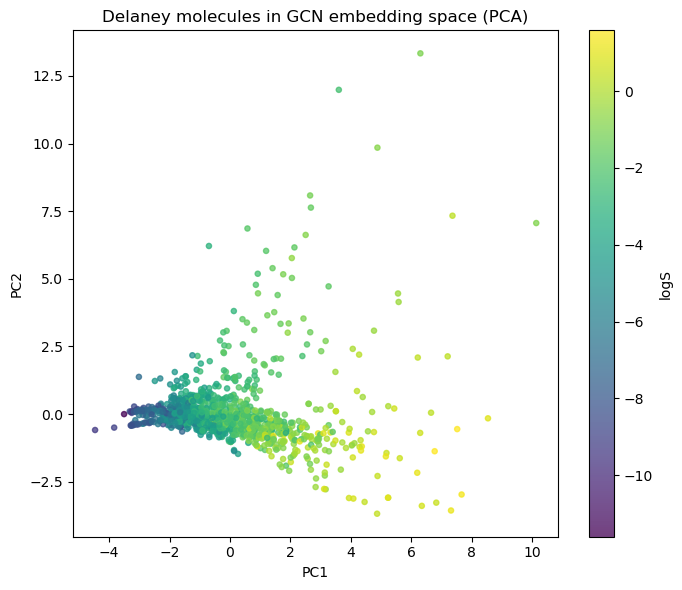

In [24]:
fig

In [25]:
# 7b. Atom embeddings — PCA, colored by element
X_atom = atom_all[atom_emb_cols].values
labels = atom_all["atom"].values
Z2_atom = PCA(n_components=2, random_state=0).fit_transform(X_atom)
 
fig, ax = plt.subplots(figsize=(8, 7))
for sym in atom_all["atom"].unique():
    m = labels == sym
    ax.scatter(Z2_atom[m, 0], Z2_atom[m, 1], s=8, alpha=0.5, label=sym)
ax.legend(markerscale=2, fontsize=8, ncol=2)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Per-atom GCN embeddings, colored by element")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "atom_embeddings_pca.png"), dpi=150)
plt.close(fig)

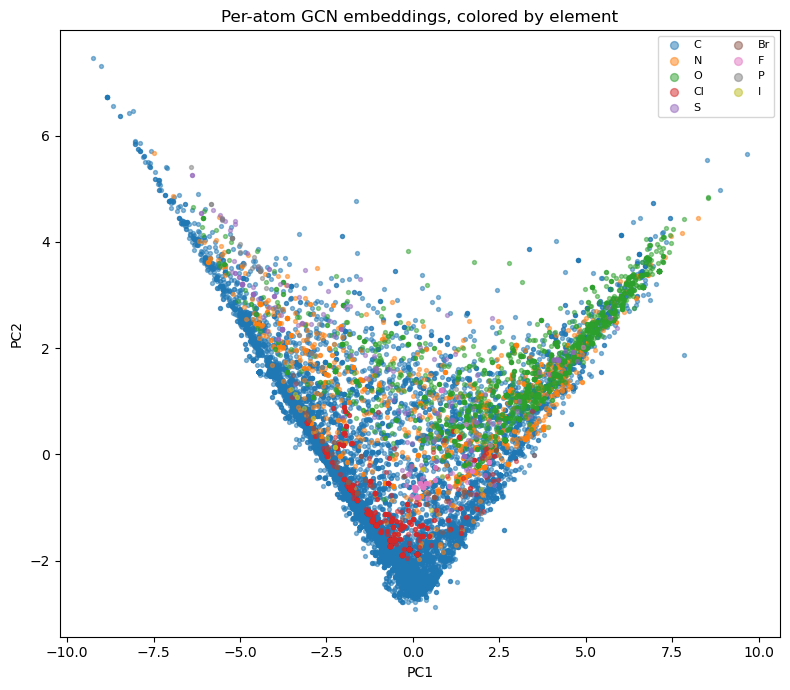

In [26]:
fig

In [27]:
# ---------------------------------------------------------------------------
# 8. Atom-level "logS contribution" — paint atoms onto the molecule
#
# We linearize the regression head (lin2 @ lin1) and project each atom's
# embedding onto the resulting vector. This is approximate (it ignores the
# ReLU and dropout) but gives a useful per-atom solubility-importance map.
# ---------------------------------------------------------------------------
W = (model.lin2.weight @ model.lin1.weight).detach().cpu().numpy().flatten()  # (hidden_dim,)
atom_all["logS_contrib"] = atom_all[atom_emb_cols].values @ W
 
# Save back with contribution column
atom_all.to_csv(atom_csv, index=False)
print(f"Added 'logS_contrib' column to {atom_csv}")
 
# Pick one molecule and color its atoms by contribution
def draw_atoms_by_value(mol_id, value_col="logS_contrib",
                        out_png=None):
    sub = atom_all[atom_all["mol_idx"] == mol_id].sort_values("atom_idx")
    smi = sub["smiles"].iloc[0]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
 
    values = sub[value_col].values
    vmin, vmax = float(values.min()), float(values.max())
    if vmin == vmax:
        vmax = vmin + 1e-6
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.cm.RdBu_r       # blue (negative) -> red (positive)
    atom_colors = {i: cmap(norm(v))[:3] for i, v in enumerate(values)}
 
    drawer = rdMolDraw2D.MolDraw2DCairo(500, 400)
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
    )
    drawer.FinishDrawing()
    out_png = out_png or os.path.join(OUTPUT_DIR, f"mol_{mol_id}_{value_col}.png")
    with open(out_png, "wb") as f:
        f.write(drawer.GetDrawingText())
    return out_png, smi, vmin, vmax
 
 
# Render a few example molecules
for mid in [0, 1, 2, 3, 4]:
    if mid in atom_all["mol_idx"].values:
        out_png, smi, vmin, vmax = draw_atoms_by_value(mid)
        print(f"Saved -> {out_png}   SMILES: {smi}   "
              f"contrib range: [{vmin:.3f}, {vmax:.3f}]")
 


Added 'logS_contrib' column to ./delaney_gnn_embeddings_run/delaney_gnn_atom_embeddings.csv
Saved -> ./delaney_gnn_embeddings_run/mol_0_logS_contrib.png   SMILES: CCCCc1c(C)nc(nc1O)N(C)C    contrib range: [-4.446, 6.485]
Saved -> ./delaney_gnn_embeddings_run/mol_1_logS_contrib.png   SMILES: CN(C)C(=O)Nc1ccc(c(Cl)c1)n2nc(oc2=O)C(C)(C)C   contrib range: [-5.284, 5.205]
Saved -> ./delaney_gnn_embeddings_run/mol_2_logS_contrib.png   SMILES: O=C1NCCN1c2ncc(s2)N(=O)=O   contrib range: [-1.073, 6.679]
Saved -> ./delaney_gnn_embeddings_run/mol_3_logS_contrib.png   SMILES: Clc1cc(Cl)c(cc1Cl)c2cc(Cl)c(Cl)cc2Cl    contrib range: [-8.162, 6.238]
Saved -> ./delaney_gnn_embeddings_run/mol_4_logS_contrib.png   SMILES: CCOC(=O)C   contrib range: [-4.831, 6.551]


In [28]:
# ---------------------------------------------------------------------------
# 9. Sanity check — Random Forest on GCN molecule embeddings
#    A high R^2 here means the GCN actually packed solubility-relevant
#    information into the embedding space.
# ---------------------------------------------------------------------------
X_tr = emb_train[mol_emb_cols].values
X_te = emb_test [mol_emb_cols].values
y_tr = emb_train["logS"].values
y_te = emb_test ["logS"].values
 
rf = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1).fit(X_tr, y_tr)
rf_r2   = r2_score(y_te, rf.predict(X_te))
rf_rmse = float(np.sqrt(mean_squared_error(y_te, rf.predict(X_te))))
print(f"\nRF on GCN molecule embeddings, test R^2 = {rf_r2:.3f}   RMSE = {rf_rmse:.3f}")


RF on GCN molecule embeddings, test R^2 = 0.934   RMSE = 0.528


In [29]:
# ---------------------------------------------------------------------------
# 10. Save the trained model for re-use
# ---------------------------------------------------------------------------
ckpt_path = os.path.join(OUTPUT_DIR, "gcn_delaney.pt")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "in_dim":     dataset.num_node_features,
            "hidden_dim": HIDDEN_DIM,
            "dropout":    DROPOUT,
            "y_mean":     y_mean,
            "y_std":      y_std,
        },
    },
    ckpt_path,
)
print(f"\nSaved model    -> {ckpt_path}")
print(f"Outputs folder -> {OUTPUT_DIR}")


Saved model    -> ./delaney_gnn_embeddings_run/gcn_delaney.pt
Outputs folder -> ./delaney_gnn_embeddings_run


Molecule 0  SMILES: CCCCc1c(C)nc(nc1O)N(C)C 


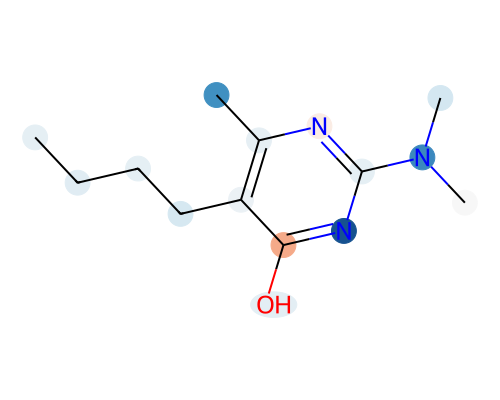

Molecule 1  SMILES: CN(C)C(=O)Nc1ccc(c(Cl)c1)n2nc(oc2=O)C(C)(C)C


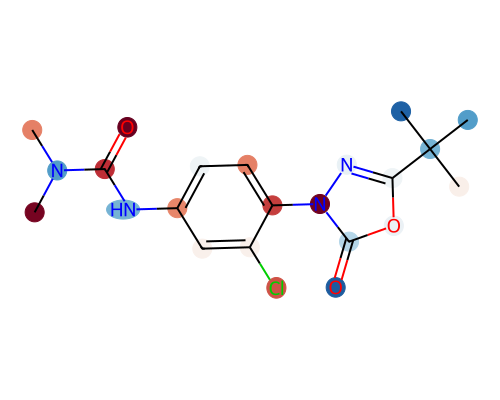

Molecule 2  SMILES: O=C1NCCN1c2ncc(s2)N(=O)=O


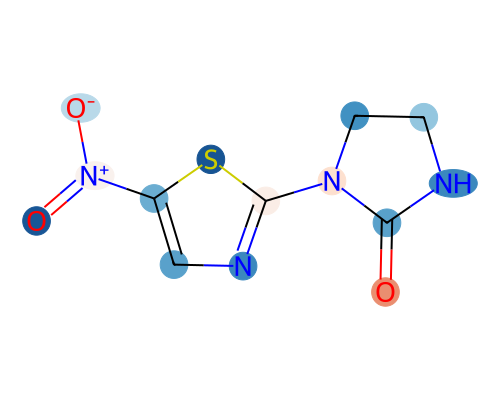

Molecule 3  SMILES: Clc1cc(Cl)c(cc1Cl)c2cc(Cl)c(Cl)cc2Cl 


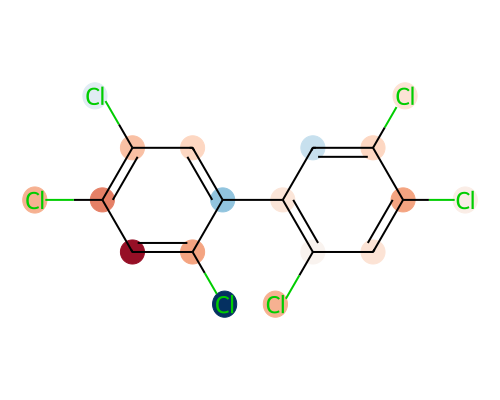

Molecule 4  SMILES: CCOC(=O)C


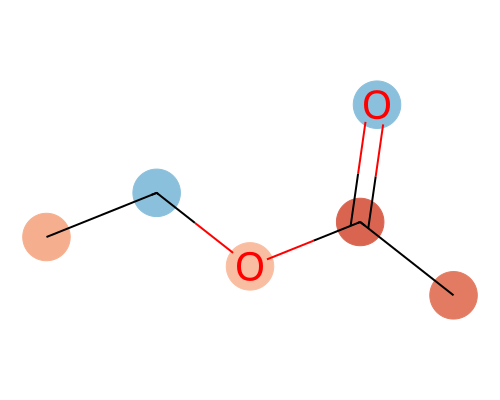

In [30]:
from IPython.display import Image, display

for mid in [0, 1, 2, 3, 4]:
    if mid in atom_all["mol_idx"].values:
        path = os.path.join(OUTPUT_DIR, f"mol_{mid}_logS_contrib.png")
        smi  = atom_all.loc[atom_all["mol_idx"] == mid, "smiles"].iloc[0]
        print(f"Molecule {mid}  SMILES: {smi}")
        display(Image(filename=path))

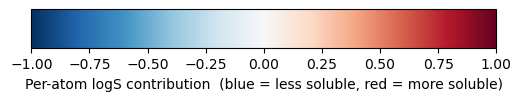

In [31]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(6, 0.5))
sm = ScalarMappable(norm=Normalize(vmin=-1, vmax=1), cmap="RdBu_r")
fig.colorbar(sm, cax=ax, orientation="horizontal",
             label="Per-atom logS contribution  (blue = less soluble, red = more soluble)")
plt.show()

In [32]:
print("Layer-by-layer embeddings (see what each conv layer adds)")

Layer-by-layer embeddings (see what each conv layer adds)


In [33]:
print('''

Understanding intermediate GCN representations

A Graph Convolutional Network (GCN) processes a molecule progressively, one layer at a time. 
Each successive convolution expands the structural neighborhood that every atom can <see>

Layer-by-layer intuition

1. After the first GCN layer:

each atom has incorporated information from its directly bonded neighbors this corresponds to a 1-bond radius

So the hidden representation now captures:

atom identity
immediate chemical environment
local bonding context

2. After the second GCN layer:

atoms now receive information from neighbors-of-neighbors
the receptive field expands to a 2-bond radius

At this stage the representation starts capturing:

small functional groups
short-range structural motifs
local aromatic environments

3. After the third GCN layer:

information has propagated across atoms up to 3 bonds away
each atom representation now encodes broader molecular context

This begins to resemble:

scaffold-level information
substructure interactions
global molecular organization
What the original model does

In the original script, the model computes intermediate hidden states:

h1 → h2 → h3

but only the final representation (h3) is actually used for prediction.

Typically the pipeline looks like:

atoms
  ↓
GCN layer 1 → h1
  ↓
GCN layer 2 → h2
  ↓
GCN layer 3 → h3
  ↓
global pooling
  ↓
molecule embedding
  ↓
prediction

So although:

h1
h2

already contain meaningful learned chemistry representations, they are discarded during inference.

Why extracting h1, h2, and h3 is useful

Each intermediate layer represents the molecule at a different level of abstraction.

Layer	Representation level
h1	local atom identity
h2	functional-group context
h3	broader molecular structure

Extracting all layers allows you to observe how the model gradually transforms the representation from:

<What kind of atom is this? > into: <What kind of molecule is this?>

This is extremely valuable for:

interpretability
embedding analysis
dimensionality reduction (UMAP/t-SNE)
trajectory visualization during training
comparing molecular similarity across layers

''')



Understanding intermediate GCN representations

A Graph Convolutional Network (GCN) processes a molecule progressively, one layer at a time. 
Each successive convolution expands the structural neighborhood that every atom can <see>

Layer-by-layer intuition

1. After the first GCN layer:

each atom has incorporated information from its directly bonded neighbors this corresponds to a 1-bond radius

So the hidden representation now captures:

atom identity
immediate chemical environment
local bonding context

2. After the second GCN layer:

atoms now receive information from neighbors-of-neighbors
the receptive field expands to a 2-bond radius

At this stage the representation starts capturing:

small functional groups
short-range structural motifs
local aromatic environments

3. After the third GCN layer:

information has propagated across atoms up to 3 bonds away
each atom representation now encodes broader molecular context

This begins to resemble:

scaffold-level information
subst

In [34]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool

@torch.no_grad()
def get_layered_embeddings(loader):
    """
    Returns three (n_mols, hidden_dim) arrays — molecule embeddings pooled
    after each of the three GCN layers — plus the corresponding SMILES list.

    h1 = output of conv1 (1-bond receptive field)
    h2 = output of conv2 (2-bond receptive field)
    h3 = output of conv3 (3-bond receptive field — same as model.embed())
    """
    model.eval()
    h1s, h2s, h3s, smiles_all = [], [], [], []
    for data in loader:
        data = data.to(device)
        x  = data.x.float()
        ei = data.edge_index

        # Three layers, captured one by one
        h1 = F.relu(model.bn1(model.conv1(x,  ei)))
        h2 = F.relu(model.bn2(model.conv2(h1, ei)))
        h3 = F.relu(model.bn3(model.conv3(h2, ei)))

        # Pool each layer to one vector per molecule in this batch
        z1 = global_mean_pool(h1, data.batch).cpu().numpy()
        z2 = global_mean_pool(h2, data.batch).cpu().numpy()
        z3 = global_mean_pool(h3, data.batch).cpu().numpy()

        h1s.append(z1); h2s.append(z2); h3s.append(z3)
        smiles_all.extend(data.smiles)

    return (
        np.concatenate(h1s, axis=0),
        np.concatenate(h2s, axis=0),
        np.concatenate(h3s, axis=0),
        smiles_all,
    )

In [35]:
# Use the non-shuffled loaders so SMILES line up with rows
train_loader_seq = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

H1_tr, H2_tr, H3_tr, S_tr = get_layered_embeddings(train_loader_seq)
H1_va, H2_va, H3_va, S_va = get_layered_embeddings(valid_loader)
H1_te, H2_te, H3_te, S_te = get_layered_embeddings(test_loader)

H1 = np.concatenate([H1_tr, H1_va, H1_te], axis=0)
H2 = np.concatenate([H2_tr, H2_va, H2_te], axis=0)
H3 = np.concatenate([H3_tr, H3_va, H3_te], axis=0)
smiles = S_tr + S_va + S_te

# Pull each molecule's true logS in the same order
y_lookup = {d.smiles: float(d.y) for d in dataset}
y = np.array([y_lookup[s] for s in smiles])

print(f"H1 shape : {H1.shape}   (after conv1)")
print(f"H2 shape : {H2.shape}   (after conv2)")
print(f"H3 shape : {H3.shape}   (after conv3 — same as model.embed())")

H1 shape : (1128, 64)   (after conv1)
H2 shape : (1128, 64)   (after conv2)
H3 shape : (1128, 64)   (after conv3 — same as model.embed())


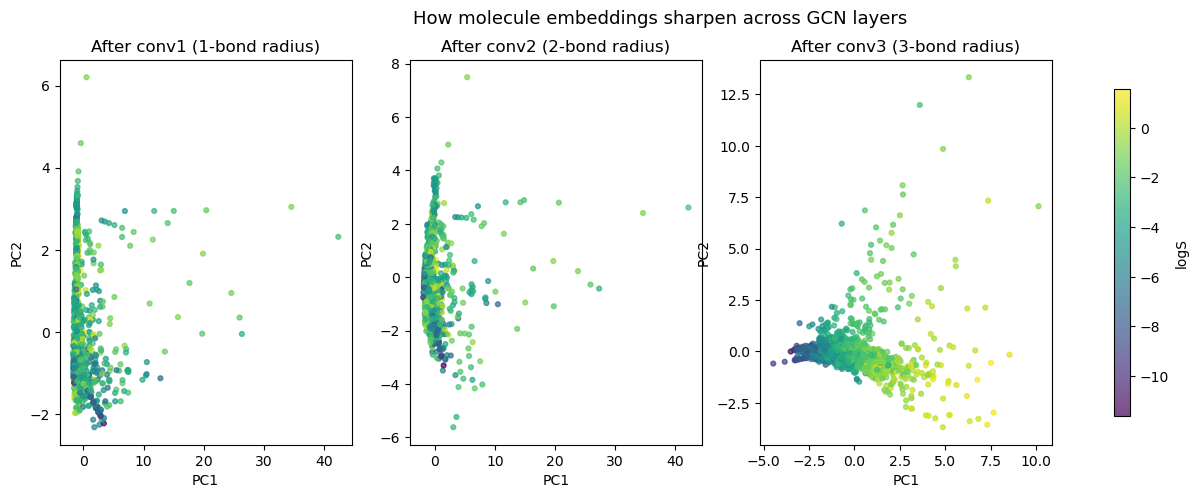

In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["After conv1 (1-bond radius)",
          "After conv2 (2-bond radius)",
          "After conv3 (3-bond radius)"]

for ax, H, title in zip(axes, [H1, H2, H3], titles):
    Z2 = PCA(n_components=2, random_state=0).fit_transform(H)
    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=y, cmap="viridis", s=12, alpha=0.7)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(title)
fig.colorbar(sc, ax=axes, label="logS", shrink=0.85)
plt.suptitle("How molecule embeddings sharpen across GCN layers", fontsize=13)
plt.savefig("layered_embeddings_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

n_tr = len(S_tr)                             # train comes first in `smiles`
y_tr = y[:n_tr]
y_te = y[n_tr + len(S_va):]                  # test comes last

for name, H in [("conv1", H1), ("conv2", H2), ("conv3", H3)]:
    Xtr = H[:n_tr]
    Xte = H[n_tr + len(S_va):]
    r = Ridge(alpha=1.0).fit(Xtr, y_tr)
    r2 = r2_score(y_te, r.predict(Xte))
    print(f"Ridge on {name} embeddings  →  test R² = {r2:.3f}")

Ridge on conv1 embeddings  →  test R² = 0.795
Ridge on conv2 embeddings  →  test R² = 0.882
Ridge on conv3 embeddings  →  test R² = 0.881


In [38]:
import pandas as pd

def to_df(H, smiles, y, layer_name):
    cols = [f"emb_{i:02d}" for i in range(H.shape[1])]        # NO layer prefix
    df = pd.DataFrame(H, columns=cols)
    df.insert(0, "logS",   y)
    df.insert(0, "smiles", smiles)
    df.insert(0, "layer",  layer_name)
    return df

df_all = pd.concat(
    [to_df(H1, smiles, y, "conv1"),
     to_df(H2, smiles, y, "conv2"),
     to_df(H3, smiles, y, "conv3")],
    ignore_index=True,
)
df_all.to_csv("delaney_layered_embeddings.csv", index=False)

print(df_all.shape)                       # (3384, 67)  -> 3 meta + 64 emb
print(df_all.head(1).to_string(index=False))
print(df_all.tail(1).to_string(index=False))

(3384, 67)
layer                   smiles  logS   emb_00   emb_01   emb_02   emb_03   emb_04   emb_05   emb_06   emb_07   emb_08   emb_09   emb_10   emb_11   emb_12  emb_13   emb_14  emb_15   emb_16   emb_17   emb_18   emb_19   emb_20   emb_21   emb_22   emb_23   emb_24   emb_25   emb_26   emb_27   emb_28   emb_29   emb_30   emb_31   emb_32   emb_33   emb_34   emb_35   emb_36   emb_37   emb_38   emb_39   emb_40   emb_41  emb_42   emb_43   emb_44   emb_45   emb_46   emb_47   emb_48   emb_49   emb_50   emb_51   emb_52   emb_53   emb_54   emb_55   emb_56   emb_57   emb_58   emb_59  emb_60  emb_61   emb_62   emb_63
conv1 CCCCc1c(C)nc(nc1O)N(C)C  -2.24 0.499491 0.382201 0.504957 0.356562 0.268282 0.234758 0.358997 0.462664 0.627333 0.305671 0.259633 0.022924 0.440462 0.26313 0.549831 0.08437 0.460377 0.624005 0.120025 0.440414 0.180149 0.140889 0.283797 0.068716 0.181294 0.085576 0.587944 0.021759 0.302687 0.364044 0.703515 0.321466 0.298337 0.348876 0.554967 0.582614 0.026291 0.316995 0.24

In [39]:
import pandas as pd

emb_cols = lambda prefix: [f"{prefix}_emb_{i:02d}" for i in range(H1.shape[1])]

df_wide = pd.concat([
    pd.DataFrame({"smiles": smiles, "logS": y}),
    pd.DataFrame(H1, columns=emb_cols("conv1")),
    pd.DataFrame(H2, columns=emb_cols("conv2")),
    pd.DataFrame(H3, columns=emb_cols("conv3")),
], axis=1)   # axis=1 = horizontal concat

df_wide.to_csv("delaney_layered_embeddings_wide.csv", index=False)
print(df_wide.shape)                      # (1128, 2 + 192) — 1 row per molecule
print(df_wide.head(1))
print(df_wide.tail(1))

(1128, 194)
                     smiles  logS  conv1_emb_00  conv1_emb_01  conv1_emb_02  \
0  CCCCc1c(C)nc(nc1O)N(C)C  -2.24      0.499491      0.382201      0.504957   

   conv1_emb_03  conv1_emb_04  conv1_emb_05  conv1_emb_06  conv1_emb_07  ...  \
0      0.356562      0.268282      0.234758      0.358997      0.462664  ...   

   conv3_emb_54  conv3_emb_55  conv3_emb_56  conv3_emb_57  conv3_emb_58  \
0        0.0803      0.061858      0.335056      0.494417      0.295826   

   conv3_emb_59  conv3_emb_60  conv3_emb_61  conv3_emb_62  conv3_emb_63  
0      0.108884      0.580912      0.270181      0.627004      0.136585  

[1 rows x 194 columns]
     smiles  logS  conv1_emb_00  conv1_emb_01  conv1_emb_02  conv1_emb_03  \
1127   CCBr -1.09      0.405789       2.18843      0.436487           0.0   

      conv1_emb_04  conv1_emb_05  conv1_emb_06  conv1_emb_07  ...  \
1127      0.184482           0.0      0.170158      0.077663  ...   

      conv3_emb_54  conv3_emb_55  conv3_emb_56  con

In [40]:
# Total rows: 3384 — that's 1128 molecules × 3 layers. Correct.
# The "first row" output is the conv1 row for molecule 0. 
# The values you see in conv1_emb_00, conv1_emb_01, … are real numbers.

In [41]:
# 1128 rows — one per molecule, no duplication. 
# (In the long version you had 3384 rows because each molecule appeared three times, once per layer.)
# 194 columns — smiles + logS + 64×3 embedding columns = 2 + 192 = 194.

In [42]:
meta_cols = ["layer", "smiles", "logS"]

print("FIRST ROW:")
print(df_all.iloc[0][meta_cols].to_string())

print("\nLAST ROW:")
print(df_all.iloc[-1][meta_cols].to_string())

FIRST ROW:
layer                        conv1
smiles    CCCCc1c(C)nc(nc1O)N(C)C 
logS                         -2.24

LAST ROW:
layer     conv3
smiles     CCBr
logS      -1.09


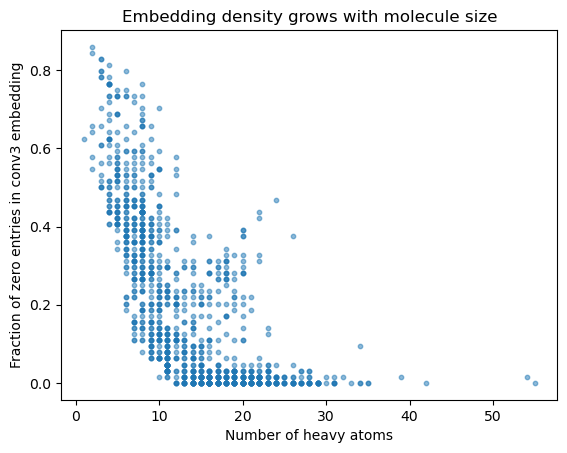

In [43]:
# Fraction of zero entries in conv3 embeddings, plotted against molecule size
import numpy as np
from rdkit import Chem

conv3 = df_wide[[c for c in df_wide.columns if c.startswith("conv3_emb_")]].values
n_heavy = df_wide["smiles"].apply(lambda s: Chem.MolFromSmiles(s).GetNumHeavyAtoms()).values
zero_frac = (conv3 == 0).mean(axis=1)

import matplotlib.pyplot as plt
plt.scatter(n_heavy, zero_frac, s=10, alpha=0.5)
plt.xlabel("Number of heavy atoms")
plt.ylabel("Fraction of zero entries in conv3 embedding")
plt.title("Embedding density grows with molecule size")
plt.show()

In [44]:
print('''

Mean-pooling on a very small molecule makes this effect especially visible. 
The final molecule embedding is computed as the average of all atom embeddings in the graph.

For a tiny molecule like CCBr, only three atom vectors contribute to that average. 
A feature dimension will remain zero unless at least one of those three atoms activates it. 
As a result, many high-level chemical features — such as those associated with aromatic rings, 
conjugated systems, or complex electronic environments — never appear in the embedding, 
simply because the molecule is too small and chemically simple to generate them.

In contrast, the pyrimidine-containing molecule in row 0 contains 19 atoms. 

During message passing, different atoms specialize in different structural contexts, 
and when all 19 embeddings are averaged together, 
at least one atom tends to activate nearly every latent feature dimension. 

The resulting molecular representation is therefore much denser and richer than that of a tiny molecule like CCBr.

''')



Mean-pooling on a very small molecule makes this effect especially visible. 
The final molecule embedding is computed as the average of all atom embeddings in the graph.

For a tiny molecule like CCBr, only three atom vectors contribute to that average. 
A feature dimension will remain zero unless at least one of those three atoms activates it. 
As a result, many high-level chemical features — such as those associated with aromatic rings, 
conjugated systems, or complex electronic environments — never appear in the embedding, 
simply because the molecule is too small and chemically simple to generate them.

In contrast, the pyrimidine-containing molecule in row 0 contains 19 atoms. 

During message passing, different atoms specialize in different structural contexts, 
and when all 19 embeddings are averaged together, 
at least one atom tends to activate nearly every latent feature dimension. 

The resulting molecular representation is therefore much denser and richer than that of a t

In [45]:
print('''

Tiny molecule (3 atoms):
atom1 + atom2 + atom3
          ↓
      sparse average embedding

Larger aromatic molecule (19 atoms):
atom1 + atom2 + ... + atom19
               ↓
      richer, denser embedding

This is one reason transformer-based SMILES models and graph neural networks often produce more informative embeddings for larger, 
structurally diverse molecules than for extremely small compounds.

''')



Tiny molecule (3 atoms):
atom1 + atom2 + atom3
          ↓
      sparse average embedding

Larger aromatic molecule (19 atoms):
atom1 + atom2 + ... + atom19
               ↓
      richer, denser embedding

This is one reason transformer-based SMILES models and graph neural networks often produce more informative embeddings for larger, 
structurally diverse molecules than for extremely small compounds.




In [46]:
print('''

You should see a clear downward trend: tiny molecules sit at high zero fractions; 
large molecules cluster near zero zero-fraction. This is the GCN's 
way of saying "smaller molecules occupy a more restricted region of feature space.

''')



You should see a clear downward trend: tiny molecules sit at high zero fractions; 
large molecules cluster near zero zero-fraction. This is the GCN's 
way of saying "smaller molecules occupy a more restricted region of feature space.


